In [2]:
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Unzip your dataset into the fast local /content/ directory
!unzip -q "/content/drive/MyDrive/Tata_Hackathon_Data/5.+Battery+Data+Set.zip" -d "/content/extracted_battery_data"

print("🎉 Unzipping complete! Check your sidebar for the 'extracted_battery_data' folder.")

🎉 Unzipping complete! Check your sidebar for the 'extracted_battery_data' folder.


In [4]:
import os

# Define the folder path where we extracted the files
data_folder = "/content/extracted_battery_data"

# List out the first 10 files or folders inside it
files = os.listdir(data_folder)
print(f"Total items found: {len(files)}")
print("First 10 items in the folder:")
print(files[:10])

Total items found: 1
First 10 items in the folder:
['5. Battery Data Set']


In [5]:
import os

# Update our path to go inside the subfolder
sub_folder_path = "/content/extracted_battery_data/5. Battery Data Set"

# Check what is inside this subfolder
inner_files = os.listdir(sub_folder_path)
print(f"Total items found inside '5. Battery Data Set': {len(inner_files)}")
print("Items:")
print(inner_files[:10])

Total items found inside '5. Battery Data Set': 6
Items:
['5. BatteryAgingARC_49_50_51_52.zip', '3. BatteryAgingARC_25-44.zip', '1. BatteryAgingARC-FY08Q4.zip', '4. BatteryAgingARC_45_46_47_48.zip', '2. BatteryAgingARC_25_26_27_28_P1.zip', '6. BatteryAgingARC_53_54_55_56.zip']


In [6]:
import os

# Path to the first nested zip file
batch1_zip = "/content/extracted_battery_data/5. Battery Data Set/1. BatteryAgingARC-FY08Q4.zip"
target_dir = "/content/batch_1"

# Unzip it
!unzip -q "{batch1_zip}" -d "{target_dir}"

# Print what's inside the newly extracted batch
print("Extraction complete! Files inside batch_1:")
print(os.listdir(target_dir))

Extraction complete! Files inside batch_1:
['B0018.mat', 'B0006.mat', 'README.txt', 'B0005.mat', 'B0007.mat']


In [7]:
import scipy.io
import pandas as pd

# 1. Load the original MATLAB file
mat = scipy.io.loadmat("/content/batch_1/B0005.mat")
core_struct = mat['B0005'][0, 0]
cycles = core_struct['cycle'][0]

all_rows = []
discharge_count = 0

# 2. Extract every single measurement row from DISCHARGE cycles
for i, cycle in enumerate(cycles):
    if cycle['type'][0] == 'discharge':
        discharge_count += 1

        # Extract metadata for this test run
        ambient_temp = cycle['ambient_temperature'][0, 0]
        # Clean up timestamp array format
        time_stamp = str(cycle['time'][0])

        # Access the raw time-series sensor grid
        sensor_data = cycle['data'][0, 0]

        voltage_vals = sensor_data['Voltage_measured'][0]
        current_vals = sensor_data['Current_measured'][0]
        temp_vals = sensor_data['Temperature_measured'][0]
        time_steps = sensor_data['Time'][0]
        capacity_val = sensor_data['Capacity'][0, 0]

        # Loop through every time step inside this single cycle run
        for j in range(len(time_steps)):
            all_rows.append({
                'Discharge_Cycle': discharge_count,
                'Ambient_Temperature': ambient_temp,
                'Time_Seconds': time_steps[j],
                'Voltage_Measured': voltage_vals[j],
                'Current_Measured': current_vals[j],
                'Temperature_Measured': temp_vals[j],
                'Capacity_Ah': capacity_val
            })

# 3. Pack everything into a flat DataFrame and save to CSV
df_flat = pd.DataFrame(all_rows)
df_flat.to_csv("/content/battery_B0005_flattened.csv", index=False)

print(f"🎉 Success! Flattened {len(df_flat)} rows of sensor data.")
print("Saved as: /content/battery_B0005_flattened.csv")

🎉 Success! Flattened 50285 rows of sensor data.
Saved as: /content/battery_B0005_flattened.csv


In [8]:
df=pd.read_csv("/content/battery_B0005_flattened.csv")
df.head()

,Discharge_Cycle,Ambient_Temperature,Time_Seconds,Voltage_Measured,Current_Measured,Temperature_Measured,Capacity_Ah
0,1,24,0.000,4.191492,-0.004902,24.330034,1.856487
1,1,24,16.781,4.190749,-0.001478,24.325993,1.856487
2,1,24,35.703,3.974871,-2.012528,24.389085,1.856487
3,1,24,53.781,3.951717,-2.013979,24.544752,1.856487
4,1,24,71.922,3.934352,-2.011144,24.731385,1.856487


In [9]:
print("no of rows=",df.shape[0])
print("no of column=",df.shape[1])

no of rows= 50285
no of column= 7


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50285 entries, 0 to 50284
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Discharge_Cycle       50285 non-null  int64  
 1   Ambient_Temperature   50285 non-null  int64  
 2   Time_Seconds          50285 non-null  float64
 3   Voltage_Measured      50285 non-null  float64
 4   Current_Measured      50285 non-null  float64
 5   Temperature_Measured  50285 non-null  float64
 6   Capacity_Ah           50285 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 2.7 MB


In [11]:
df.describe()


,Discharge_Cycle,Ambient_Temperature,Time_Seconds,Voltage_Measured,Current_Measured,Temperature_Measured,Capacity_Ah
count,50285.000000,50285.0,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000
mean,88.125942,24.0,1546.208924,3.515268,-1.806032,32.816991,1.560345
std,45.699687,0.0,906.640295,0.231778,0.610502,3.987515,0.182380
min,1.000000,24.0,0.000000,2.455679,-2.029098,23.214802,1.287453
25%,50.000000,24.0,768.563000,3.399384,-2.013415,30.019392,1.386229
50%,88.000000,24.0,1537.031000,3.511664,-2.012312,32.828944,1.538237
75%,127.000000,24.0,2305.984000,3.660903,-2.011052,35.920887,1.746871
max,168.000000,24.0,3690.234000,4.222920,0.007496,41.450232,1.856487


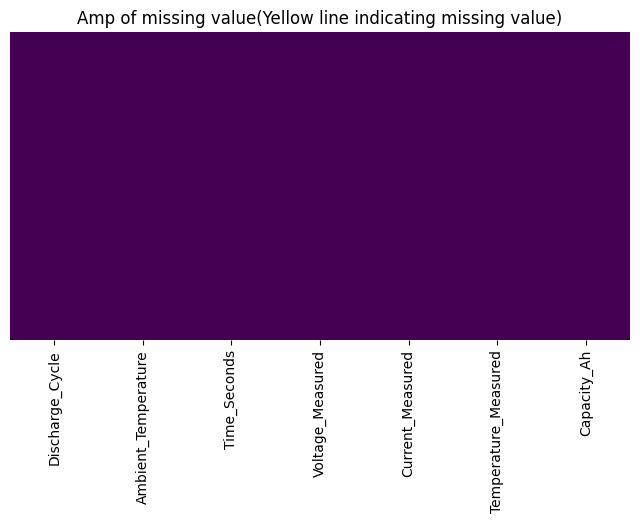

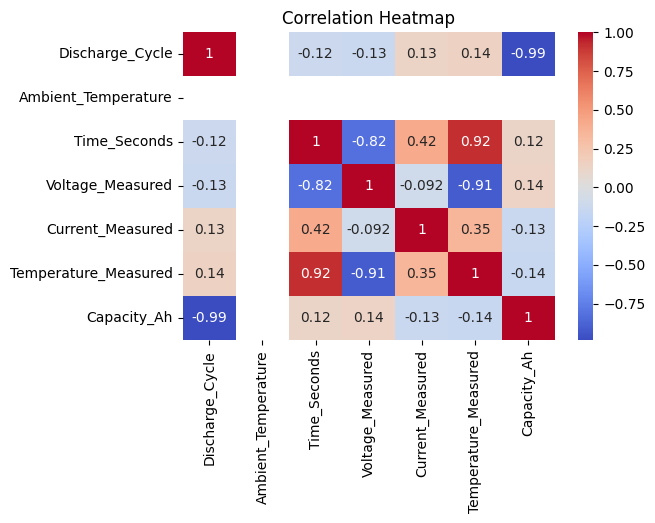

/tmp/ipykernel_16473/31486296.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Capacity_Ah', palette='Set2')


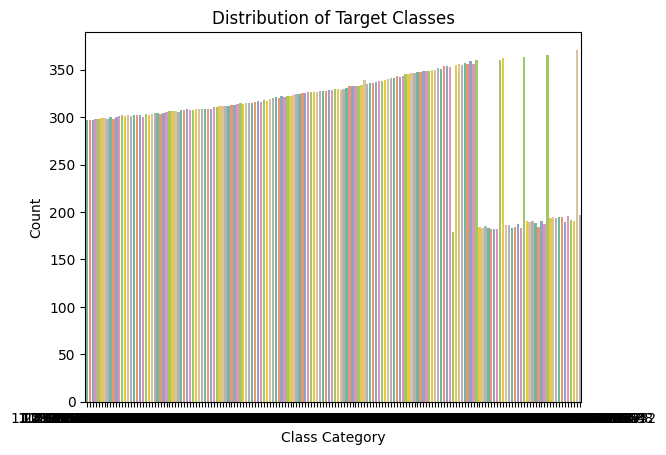

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(),cbar=False, yticklabels=False, cmap='viridis')
plt.title('Amp of missing value(Yellow line indicating missing value)')
plt.show()
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
sns.countplot(data=df, x='Capacity_Ah', palette='Set2')
plt.title("Distribution of Target Classes")
plt.xlabel("Class Category")
plt.ylabel("Count")
plt.show()

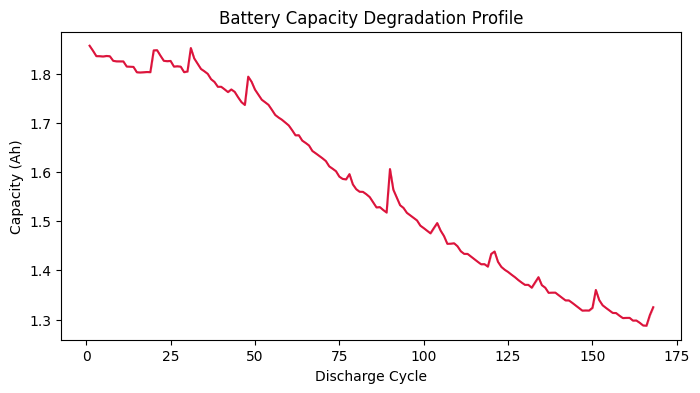

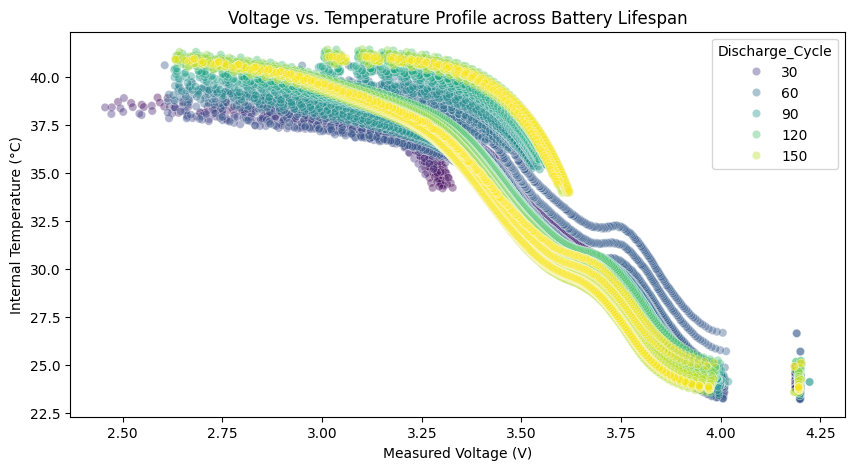

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
# Lineplot automatically handles averaging multiple time points per cycle
sns.lineplot(data=df, x='Discharge_Cycle', y='Capacity_Ah', color='crimson')
plt.title('Battery Capacity Degradation Profile')
plt.xlabel('Discharge Cycle')
plt.ylabel('Capacity (Ah)')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x='Voltage_Measured',
    y='Temperature_Measured',
    hue='Discharge_Cycle',  # Darker colors will show later stages of battery life
    palette='viridis',
    alpha=0.4
)
plt.title('Voltage vs. Temperature Profile across Battery Lifespan')
plt.xlabel('Measured Voltage (V)')
plt.ylabel('Internal Temperature (°C)')
plt.show()

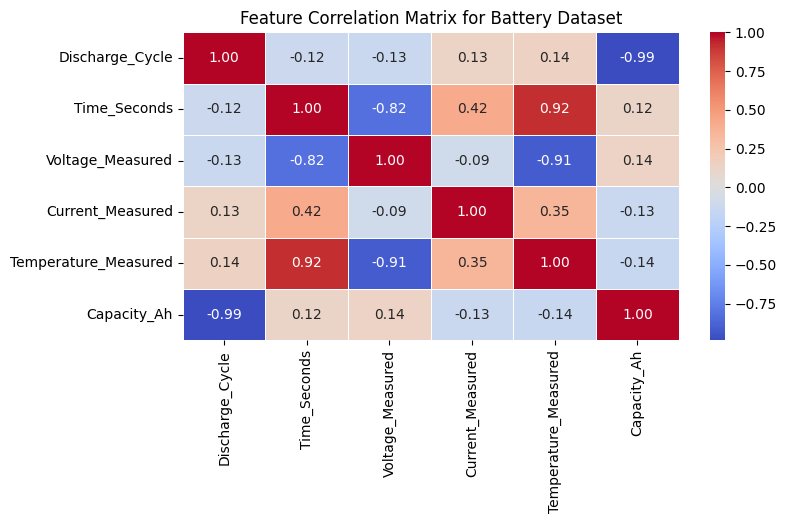

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

# 1. Drop the constant column we discovered earlier
df_numeric = df.drop(columns=['Ambient_Temperature'], errors='ignore')

# 2. Calculate the correlation matrix
corr_matrix = df_numeric.corr()

# 3. Plot the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          # Overlays the exact correlation numbers
    cmap='coolwarm',     # Red = Positive Correlation, Blue = Negative Correlation
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5       # Adds clean borders between squares
)

plt.title('Feature Correlation Matrix for Battery Dataset')
plt.show()

In [22]:
# 1. Define your features (X) and your target label (y)
# We drop Capacity_Ah because that's our target.
X = df_numeric.drop(columns=['Capacity_Ah','Ambient_Temperature', 'Time_Seconds'],errors='ignore')
y = df_numeric['Capacity_Ah']

print("--- Feature Matrix (X) Shape ---")
print(X.shape)
print("\n--- Target Vector (y) Shape ---")
print(y.shape)

--- Feature Matrix (X) Shape ---
(50285, 4)

--- Target Vector (y) Shape ---
(50285,)


Splitting data Set into Train and Test Set

In [29]:
# 1. Choose a cutoff cycle (e.g., train on the first 135 cycles, test on the final remaining ones)
cutoff_cycle = 135

# 2. Split based on the actual cycle groups to prevent leakage
train_mask = df['Discharge_Cycle'] <= cutoff_cycle
test_mask = df['Discharge_Cycle'] > cutoff_cycle

# 3. Separate features and target using our masks
X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print(f"✅ Training on cycles up to {cutoff_cycle} ({X_train.shape[0]} rows)")
print(f"✅ Testing on completely unseen future cycles ({X_test.shape[0]} rows)")

✅ Training on cycles up to 135 (40333 rows)
✅ Testing on completely unseen future cycles (9952 rows)


In [32]:
import numpy as np

# 1. Get an array of all unique cycles and shuffle them randomly
unique_cycles = df['Discharge_Cycle'].unique()
np.random.seed(42)
np.random.shuffle(unique_cycles)

# 2. Use 80% of the cycles for training, 20% for testing
split_idx = int(len(unique_cycles) * 0.8)
train_cycles = unique_cycles[:split_idx]
test_cycles = unique_cycles[split_idx:]

# 3. Create masks based on these shuffled cycles
X_train = X[df['Discharge_Cycle'].isin(train_cycles)]
y_train = y[df['Discharge_Cycle'].isin(train_cycles)]

X_test = X[df['Discharge_Cycle'].isin(test_cycles)]
y_test = y[df['Discharge_Cycle'].isin(test_cycles)]

print(f"Training on {len(train_cycles)} random cycles across the lifetime.")
print(f"Testing on {len(test_cycles)} completely hidden cycles.")

Training on 134 random cycles across the lifetime.
Testing on 34 completely hidden cycles.


In [33]:
# Retrain
model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Group-Shuffled Model Performance ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f} Ah")


=== Group-Shuffled Model Performance ===
R² Score: 0.9892
RMSE: 0.0185 Ah


MODEL TRAINIG

In [30]:
from sklearn.ensemble import RandomForestClassifier # Note: For continuous values like Ah, we use Regressor!
from sklearn.ensemble import RandomForestRegressor

# Initialize the model with 100 decision trees
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model!
print("⏳ Training your Random Forest model on the battery data...")
model.fit(X_train, y_train)
print("✅ Training complete!")

⏳ Training your Random Forest model on the battery data...
✅ Training complete!


In [31]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Generate predictions
y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n=== Model Performance ===")
print(f"R² Score: {r2:.4f} (Closer to 1.0 is perfect)")
print(f"RMSE: {rmse:.4f} Ah (Average error deviation in Ah)")


=== Model Performance ===
R² Score: -4.7569 (Closer to 1.0 is perfect)
RMSE: 0.0507 Ah (Average error deviation in Ah)


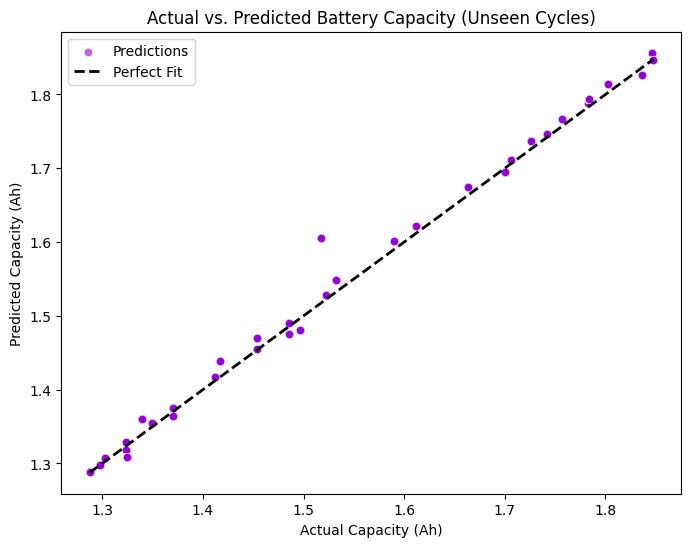

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Plot the true values against predictions
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='darkviolet', label='Predictions')

# Plot a perfect diagonal reference line (y = x)
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='black', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Actual vs. Predicted Battery Capacity (Unseen Cycles)')
plt.xlabel('Actual Capacity (Ah)')
plt.ylabel('Predicted Capacity (Ah)')
plt.legend()
plt.show()

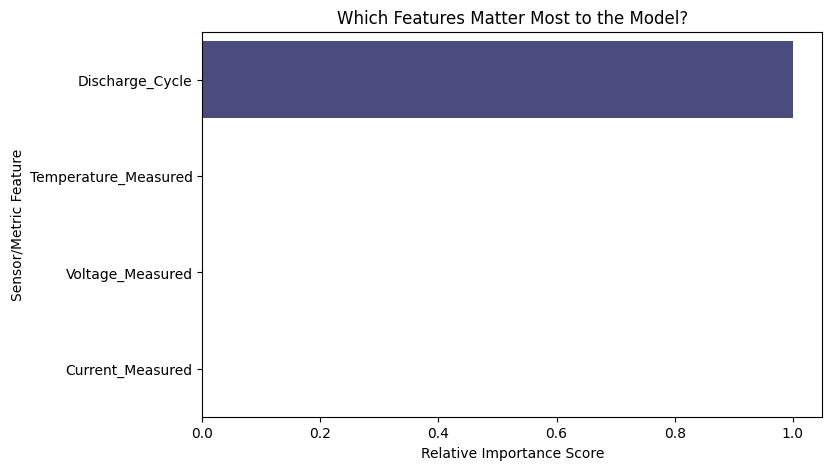

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importances from the trained model
importances = model.feature_importances_
feature_names = X.columns

# 2. Create a clean DataFrame sorted by importance
feat_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# 3. Plot using Seaborn
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_importances, x='Importance', y='Feature', hue='Feature', legend=False, palette='viridis')

plt.title('Which Features Matter Most to the Model?')
plt.xlabel('Relative Importance Score')
plt.ylabel('Sensor/Metric Feature')
plt.show()

In [36]:
# Force the model to rely ONLY on physics by dropping Discharge_Cycle
X_physics_only = df.drop(columns=['Ambient_Temperature', 'Time_Seconds', 'Discharge_Cycle', 'Capacity_Ah'], errors='ignore')
y = df['Capacity_Ah']

# Re-split using the SAME group-shuffled cycles from before so it stays fair
X_train_phys = X_physics_only[df['Discharge_Cycle'].isin(train_cycles)]
X_test_phys = X_physics_only[df['Discharge_Cycle'].isin(test_cycles)]

# Retrain the model
model_phys = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_phys.fit(X_train_phys, y_train)

# Evaluate the new purely physics-based model
y_pred_phys = model_phys.predict(X_test_phys)
r2_phys = r2_score(y_test, y_pred_phys)
rmse_phys = np.sqrt(mean_squared_error(y_test, y_pred_phys))

print("\n=== Pure Physics Model Performance (No Cycle Counter) ===")
print(f"R² Score: {r2_phys:.4f}")
print(f"RMSE: {rmse_phys:.4f} Ah")


=== Pure Physics Model Performance (No Cycle Counter) ===
R² Score: 0.5419
RMSE: 0.1203 Ah


Engineered Feature

In [37]:
# 1. Compute summary features for each individual cycle
cycle_summary = df.groupby('Discharge_Cycle').agg(
    Max_Temperature=('Temperature_Measured', 'max'),
    Min_Voltage=('Voltage_Measured', 'min'),
    Total_Discharge_Time=('Time_Seconds', 'max'),
    Target_Capacity=('Capacity_Ah', 'first') # Capacity is constant per cycle
).reset_index()

print("--- New Engineered Dataset ---")
print(cycle_summary.head())

--- New Engineered Dataset ---
   Discharge_Cycle  Max_Temperature  Min_Voltage  Total_Discharge_Time  \
0                1        38.982181     2.612467              3690.234   
1                2        39.033398     2.587209              3672.344   
2                3        38.818797     2.651917              3651.641   
3                4        38.762305     2.592948              3631.563   
4                5        38.665393     2.547420              3629.172   

   Target_Capacity  
0         1.856487  
1         1.846327  
2         1.835349  
3         1.835263  
4         1.834646  


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Define inputs and target
X_eng = cycle_summary[['Max_Temperature', 'Min_Voltage', 'Total_Discharge_Time']]
y_eng = cycle_summary['Target_Capacity']

# Split data (80% train, 20% test)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)

# Train the model
model_eng = RandomForestRegressor(n_estimators=100, random_state=42)
model_eng.fit(X_train_e, y_train_e)

# Evaluate
y_pred_e = model_eng.predict(X_test_e)
print("\n=== Engineered Physics Model Performance ===")
print(f"R² Score: {r2_score(y_test_e, y_pred_e):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_e, y_pred_e)):.4f} Ah")


=== Engineered Physics Model Performance ===
R² Score: 0.9962
RMSE: 0.0118 Ah


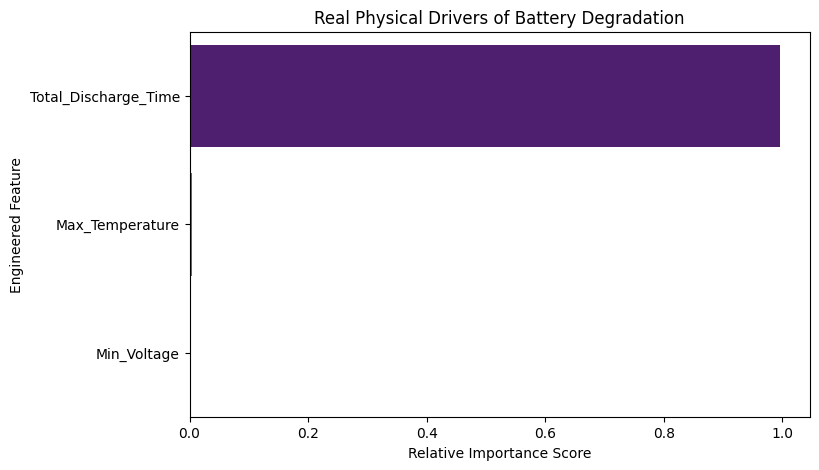

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from our engineered physics model
importances_eng = model_eng.feature_importances_
feature_names_eng = X_eng.columns

feat_importances_eng = pd.DataFrame({'Feature': feature_names_eng, 'Importance': importances_eng})
feat_importances_eng = feat_importances_eng.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_importances_eng, x='Importance', y='Feature', hue='Feature', legend=False, palette='magma')

plt.title('Real Physical Drivers of Battery Degradation')
plt.xlabel('Relative Importance Score')
plt.ylabel('Engineered Feature')
plt.show()